In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

seed = 1234
np.random.seed(seed)
pd.set_option('display.max_columns', None)

In [12]:
"""
Read Original Dataset into a Pandas DataFrame
"""
df_full = pd.read_csv("./diabetes/diabetic_data.csv")
df_full.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
df_full.shape

(101766, 50)

In [15]:
df_full.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [16]:
df_full_categorical = df_full.select_dtypes(exclude='number')
for col in df_full_categorical.columns.values:
    print(f"{col}: ", df_full[col].unique(), end='\n\n')

race:  ['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']

gender:  ['Female' 'Male' 'Unknown/Invalid']

age:  ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']

weight:  ['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']

payer_code:  ['?' 'MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']

medical_specialty:  ['Pediatrics-Endocrinology' '?' 'InternalMedicine'
 'Family/GeneralPractice' 'Cardiology' 'Surgery-General' 'Orthopedics'
 'Gastroenterology' 'Surgery-Cardiovascular/Thoracic' 'Nephrology'
 'Orthopedics-Reconstructive' 'Psychiatry' 'Emergency/Trauma'
 'Pulmonology' 'Surgery-Neuro' 'Obsterics&Gynecology-GynecologicOnco'
 'ObstetricsandGynecology' 'Pediatrics' 'Hematology/Oncology'
 'Otolaryngology' 'Surgery-Colon&Rectal' 'Pediatrics-CriticalCare'
 'Endocrinology' 'Urology' 'Psychiatry-Child/Adolescent'
 'Pediatrics-Pulmonology' 'N

In [17]:
"""
Imputing with NaN to get True NaN missing value counts

"""
missing_cols = ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'gender']

column_to_missing = {}
for col in missing_cols:
    if col != 'gender':
        column_to_missing[col] = '?'
    else:
        column_to_missing[col] = 'Unknown/Invalid'

df_1 = df_full.copy()
for col, miss_val in column_to_missing.items():
    df_1[col] = df_1[col].replace(miss_val, np.nan)
    
message = "True Missing Counts:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().sum()

True Missing Counts:


encounter_id                    0
patient_nbr                     0
race                         2273
gender                          3
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [18]:
message = "Percentage of Missing Values:"
print(message, "\n", "="*len(message), sep='')
df_1.isnull().mean().round(4)*100

Percentage of Missing Values:


encounter_id                 0.00
patient_nbr                  0.00
race                         2.23
gender                       0.00
age                          0.00
weight                      96.86
admission_type_id            0.00
discharge_disposition_id     0.00
admission_source_id          0.00
time_in_hospital             0.00
payer_code                  39.56
medical_specialty           49.08
num_lab_procedures           0.00
num_procedures               0.00
num_medications              0.00
number_outpatient            0.00
number_emergency             0.00
number_inpatient             0.00
diag_1                       0.02
diag_2                       0.35
diag_3                       1.40
number_diagnoses             0.00
max_glu_serum               94.75
A1Cresult                   83.28
metformin                    0.00
repaglinide                  0.00
nateglinide                  0.00
chlorpropamide               0.00
glimepiride                  0.00
acetohexamide 

In [19]:
missing_pct = df_1.isnull().mean() * 100

missing_only = missing_pct[missing_pct > 0].sort_values(ascending=False)

message = "Feature         |    Missing Value(%)"
print(message, '\n', "="*len(message),sep='')
print(missing_only)

Feature         |    Missing Value(%)
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
gender                0.002948
dtype: float64


---
### Grouping Data Together

In [20]:
"""
Diagnosis Groups:

Grouping based on ICD9 Grouping (source: Wikipedia)
"""
diags_ICD9_dict = {
    '001–139': 'infectious and parasitic diseases',
    '140–239': 'neoplasms',
    '240–279': 'endocrine, nutritional and metabolic diseases, and immunity disorders',
    '280–289': 'diseases of the blood and blood-forming organs',
    '290–319': 'mental disorders',
    '320–389': 'diseases of the nervous system and sense organs',
    '390–459': 'diseases of the circulatory system',
    '460–519': 'diseases of the respiratory system',
    '520–579': 'diseases of the digestive system',
    '580–629': 'diseases of the genitourinary system',
    '630–679': 'complications of pregnancy, childbirth, and the puerperium',
    '680–709': 'diseases of the skin and subcutaneous tissue',
    '710–739': 'diseases of the musculoskeletal system and connective tissue',
    '740–759': 'congenital anomalies',
    '760–779': 'certain conditions originating in the perinatal period',
    '780–799': 'symptoms, signs, and ill-defined conditions',
    '800–999': 'injury and poisoning',
    'E & V codes': 'external causes of injury and supplemental classification',
}

def categorize_diag(code: str) -> str:
    code_float = float(code)
    code_int = int(code_float)
    if code_int >= 800:
        return '800–999'
    elif code_int >= 780:
        return '780–799'
    elif code_int >= 760:
        return '760–779'
    elif code_int >= 740:
        return '740–759'
    elif code_int >= 710:
        return '710–739'
    elif code_int >= 680:
        return '680–709'
    elif code_int >= 630:
        return '630–679'
    elif code_int >= 580:
        return '580–629'
    elif code_int >= 520:
        return '520–579'
    elif code_int >= 460:
        return '460–519'
    elif code_int >= 390:
        return '390–459'
    elif code_int >= 320:
        return '320–389'
    elif code_int >= 290:
        return '290–319'
    elif code_int >= 280:
        return '280–289'
    elif code_int >= 240:
        return '240–279'
    elif code_int >= 140:
        return '140–239'
    else:
        return '001–139'

def convert_EV_code(code: str) -> str:
    return 'E & V codes'


"""
Medical Specialty Groups:

Grouping based on Google Gemini output
"""

specialty_mapping = {
    'PrimaryCare': [
        'Family/GeneralPractice', 'InternalMedicine', 'Hospitalist', 
        'Osteopath', 'Resident'
    ],
    'Surgery': [
        'Surgery-General', 'Surgery-Vascular', 'Urology', 'Surgery-Neuro', 
        'Orthopedics-Reconstructive', 'Surgery-Cardiovascular/Thoracic', 
        'Orthopedics', 'Surgery-Plastic', 'Podiatry', 'Surgery-Thoracic', 
        'Surgery-Colon&Rectal', 'Otolaryngology', 'Surgery-Cardiovascular', 
        'Surgeon', 'Proctology', 'Surgery-Maxillofacial', 'SurgicalSpecialty', 
        'Dentistry', 'Ophthalmology', 'Surgery-PlasticwithinHeadandNeck'
    ],
    'InternalMedicine_Subspecialty': [
        'Cardiology', 'Gastroenterology', 'Nephrology', 'Pulmonology', 
        'Neurology', 'Hematology/Oncology', 'Endocrinology-Metabolism', 
        'Hematology', 'Oncology', 'Endocrinology', 'InfectiousDiseases', 
        'Rheumatology', 'AllergyandImmunology', 'Neurophysiology', 'Dermatology'
    ],
    'Emergency_CriticalCare': [
        'Emergency/Trauma'
    ],
    'Maternal_Pediatric': [
        'ObstetricsandGynecology', 'Pediatrics-CriticalCare', 'Pediatrics-Endocrinology', 
        'Pediatrics', 'Gynecology', 'Pediatrics-Pulmonology', 'Pediatrics-Neurology', 
        'Obsterics&Gynecology-GynecologicOnco', 'Pediatrics-AllergyandImmunology', 
        'Cardiology-Pediatric', 'Anesthesiology-Pediatric', 'Obstetrics', 
        'Surgery-Pediatric', 'Perinatology', 'Pediatrics-EmergencyMedicine', 
        'Pediatrics-Hematology-Oncology', 'Psychiatry-Child/Adolescent', 
        'Pediatrics-InfectiousDiseases'
    ],
    'Psych_Rehab_Support': [
        'PhysicalMedicineandRehabilitation', 'Psychiatry', 'Psychology', 
        'Anesthesiology', 'Speech', 'SportsMedicine'
    ],
    'Diagnostics_Other': [
        'Radiologist', 'Radiology', 'Pathology', 'OutreachServices', 'DCPTEAM'
    ],
    'Missing': [
        'PhysicianNotFound'
    ]
}

def map_specialty_to_group(specialty):
    if pd.isna(specialty):
        return specialty
    for key, value in specialty_mapping.items():
        if specialty in value:
            return key
    return 'Other'

def build_map_to_none(categories : list[int]):
    def map_to_one(category):
        if category in categories:
            return np.nan
        return category
    return map_to_one

---
## Starting Feature Transformations & Imputation

### Grouping Transformations

In [22]:
"""
Grouping Transformations (4 total)

2 types: diagnosis and medical specialty
"""

"""
Categorizing diagnoses codes into diagnosis groups => reduces features.

Applies to: `diag_1`, `diag_2`, & `diag_3`
"""
df_2 = df_1.copy()
for i in range(1,4):

    mask = df_2[f'diag_{i}'].str.contains('^[EV]', regex=True, na=False)
    mask_nan = df_2[f'diag_{i}'].isna()
    combined_mask = mask | mask_nan
    
    df_2.loc[~combined_mask, f'diag_{i}'] = df_2.loc[~combined_mask, f'diag_{i}'].apply(categorize_diag)
    df_2.loc[mask, f'diag_{i}'] = df_2.loc[mask, f'diag_{i}'].apply(convert_EV_code)
    print(f"diag_{i}: ", df_2[f'diag_{i}'].unique(), end='\n\n')

"""
Based on medical specialty => reduces total features

Applies to: `medical_specialty`
"""
df_2['medical_specialty'] = df_2['medical_specialty'].apply(map_specialty_to_group)
print("medical_specialty: ", df_2['medical_specialty'].unique(), end = "\n\n")

"""
Categorizing ambiguous mappings together.

For example, admission_source_id has categories 9, 15, 17, 20, and 21, which map to
Not availble, not availible, Null, not mapped, unknown

Group 9, 15, 17, 20 and 21 together to null. Reduces features & remove noise

Applies to `admission_type_id`, `discharge_disposition_id`, `admission_source_id`
"""
df_2['admission_type_id'] = df_2['admission_type_id'].apply(build_map_to_none([5, 6, 8]))
df_2['discharge_disposition_id'] = df_2['discharge_disposition_id'].apply(build_map_to_none([18, 25, 26]))
df_2['admission_source_id'] = df_2['admission_source_id'].apply(build_map_to_none([9, 15, 17, 20, 21]))

print("admission_type_id: ", np.sort(df_2['admission_type_id'].unique()), end = "\n\n")
print("discharge_disposition_id: ", np.sort(df_2['discharge_disposition_id'].unique()), end = "\n\n")
print("admission_source_id: ", np.sort(df_2['admission_source_id'].unique()), end = "\n\n")

diag_1:  ['240–279' '630–679' '001–139' '140–239' '390–459' '460–519' '800–999'
 '680–709' '710–739' '520–579' 'E & V codes' '780–799' '580–629' '290–319'
 '320–389' '280–289' nan '740–759']

diag_2:  [nan '240–279' '140–239' '390–459' '460–519' '280–289' '800–999' '710–739'
 '580–629' '001–139' '520–579' '680–709' 'E & V codes' '320–389' '780–799'
 '290–319' '630–679' '740–759']

diag_3:  [nan '240–279' 'E & V codes' '390–459' '001–139' '460–519' '800–999'
 '140–239' '580–629' '710–739' '780–799' '520–579' '680–709' '290–319'
 '740–759' '320–389' '630–679' '280–289']

medical_specialty:  ['Maternal_Pediatric' nan 'PrimaryCare' 'InternalMedicine_Subspecialty'
 'Surgery' 'Psych_Rehab_Support' 'Emergency_CriticalCare'
 'Diagnostics_Other' 'Other' 'Missing']

admission_type_id:  [ 1.  2.  3.  4.  7. nan]

discharge_disposition_id:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 19.
 20. 22. 23. 24. 27. 28. nan]

admission_source_id:  [ 1.  2.  3.  4.  5.  6.  7.  8. 

### Dropping Columns

In [23]:
"""
Feature Drops:

Reasoning: 
- feature has missing 90+% of values (weight)
- feature only consists of 1 unique value
"""
df_3 = df_2.copy()
df_3.drop(columns=['weight', 'examide', 'citoglipton'], inplace=True)
print("Shape BEFORE drops: ", df_2.shape)
print("Shape AFTER drops: ", df_3.shape)

Shape BEFORE drops:  (101766, 50)
Shape AFTER drops:  (101766, 47)


### Mode Impute

In [24]:
"""
Mode Imputation
"""
df_4 = df_3.copy()
mode_impute_col_names = ['race', 'payer_code', 'medical_specialty', 'gender', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

def mode_impute(df_column):
    mask = df_column.notna()
    mode = df_column[mask].mode()[0]
    print(f"Mode:\t\t", mode)
    updated_df_column = df_column.fillna(mode)
    return updated_df_column

for name in mode_impute_col_names:
    print(name, end=' ')
    df_4[name] = mode_impute(df_4[name])

race Mode:		 Caucasian
payer_code Mode:		 MC
medical_specialty Mode:		 PrimaryCare
gender Mode:		 Female
diag_1 Mode:		 390–459
diag_2 Mode:		 390–459
diag_3 Mode:		 390–459
admission_type_id Mode:		 1.0
discharge_disposition_id Mode:		 1.0
admission_source_id Mode:		 7.0


In [26]:
message = "Before Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_3[mode_impute_col_names].isnull().sum()

Before Mode Impute:


race                         2273
payer_code                  40256
medical_specialty           49949
gender                          3
diag_1                         21
diag_2                        358
diag_3                       1423
admission_type_id           10396
discharge_disposition_id     4680
admission_source_id          7067
dtype: int64

In [27]:
message = "After Mode Impute:"
print(message, '\n', "="*len(message), sep='')
df_4[mode_impute_col_names].isnull().sum()

After Mode Impute:


race                        0
payer_code                  0
medical_specialty           0
gender                      0
diag_1                      0
diag_2                      0
diag_3                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
dtype: int64

In [28]:
"""
NaN Replacement:

Treating Unknown as a possible valid value.

Applies to: 'max_glu_serum', 'A1Cresult'

Based on potential significance of these values missing.
"""
df_5 = df_4.copy()
col_names = ['max_glu_serum', 'A1Cresult']

for name in col_names:
    df_5[name] = df_5[name].replace(np.nan, 'Unknown')

---
## Start Encoding

In [29]:
df_5_non_numeric = df_5.select_dtypes(exclude='number')

categorical_columns = list(df_5_non_numeric.columns.values)
categorical_columns += ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

non_ordinal_cols = [categorical_columns[0]] + categorical_columns[3:8] + categorical_columns[34:]
ordinal_cols = categorical_columns[1:3] + categorical_columns[8:34]

print("categorical_columns: ", categorical_columns, end='\n\n')
print("Non Ordinal: ", non_ordinal_cols, end='\n\n')
print("Ordinal: ", ordinal_cols)

categorical_columns:  ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Non Ordinal:  ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

Ordinal:  ['gender', 'age', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 

In [30]:
"""
Define Orderings for every ordinal column
"""

quad_med = ['Down', 'No', 'Steady', 'Up']
binary_med = ['No', 'Steady']

mapping = {
    # Custom/Unique orderings
    'gender': ['Male', 'Female'],
    'age': ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'],
    'weight': ['[0-25)', '[25-50)', '[50-75)', '[75-100)', '[100-125)', '[125-150)', '[150-175)', '[175-200)', '>200'],
    'max_glu_serum': ['Unknown', 'Norm', '>200', '>300'],
    'A1Cresult': ['Unknown', 'Norm', '>7', '>8'],
    'change': ['No', 'Ch'],
    'diabetesMed': ['No', 'Yes'],
    'readmitted': ['NO', '>30', '<30'],
    
    # 3-level medication (Unique)
    'tolazamide': ['No', 'Steady', 'Up'],
    
    # 4-level medications (Repeated)
    'metformin': quad_med,
    'repaglinide': quad_med,
    'nateglinide': quad_med,
    'chlorpropamide': quad_med,
    'glimepiride': quad_med,
    'glipizide': quad_med,
    'glyburide': quad_med,
    'pioglitazone': quad_med,
    'rosiglitazone': quad_med,
    'acarbose': quad_med,
    'miglitol': quad_med,
    'insulin': quad_med,
    'glyburide-metformin': quad_med,
    
    # 2-level medications (Repeated)
    'acetohexamide': binary_med,
    'tolbutamide': binary_med,
    'troglitazone': binary_med,
    'glipizide-metformin': binary_med,
    'glimepiride-pioglitazone': binary_med,
    'metformin-rosiglitazone': binary_med,
    'metformin-pioglitazone': binary_med
}

In [31]:
"""
Performing Encodings:

First starting with Ordinal Encoding

Second doing the Non-ordinal (OneHot) Encoding
"""

df_6 = df_5.copy()

# Ordinal Encoding
for col in ordinal_cols:
    ord_enc = OrdinalEncoder(categories=[mapping[col]])
    df_6[col] = ord_enc.fit_transform(df_6[[col]])

# Non-Ordinal, One-Hot Encoding
df_6 = pd.get_dummies(df_6, columns=non_ordinal_cols, drop_first=True)

In [32]:
df_6.shape

(101766, 154)

---
## Exploratory Data Analysis
### Skew Analysis

In [37]:
"""
Skew Analysis
"""
# Skewness Thresholds
upper_bound, lower_bound = 20, -20

all_cols = df_6.columns
encoded_cols = set(df_6.filter(regex=rf"^({'|'.join(categorical_columns)})_").columns)
non_encoded_cols = [c for c in all_cols if c not in encoded_cols]

non_encoded_skews = []
for col in sorted(non_encoded_cols):
    if pd.api.types.is_numeric_dtype(df_6[col]):
        skewness = df_6[col].skew()
        if skewness > upper_bound or skewness < lower_bound:
            non_encoded_skews.append((col,skewness))

encoded_skews = []
for category in categorical_columns:
    cols = df_6.filter(regex=rf'^{category}_').columns
    if not cols.empty:
        series = df_6[cols].values.argmax(axis=1)
        group_skew = pd.Series(series).skew()
        if group_skew > upper_bound or group_skew < lower_bound:
            encoded_skews.append((category, group_skew))

non_encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))
encoded_skews.sort(reverse=True, key=lambda e: abs(e[1]))

message = "Skewed Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in non_encoded_skews:
    print(f"{col:30} Skew: {skew:.4f}")

message = "\nSkewed Non-Ordinal Columns:"
print(message, '\n', "="*len(message), sep='')

for col, skew in encoded_skews:
    print(f"Grouped {col:22} Skew: {skew:.4f}")

Skewed Ordinal Columns:
metformin-pioglitazone         Skew: 319.0078
acetohexamide                  Skew: 319.0078
glimepiride-pioglitazone       Skew: 319.0078
metformin-rosiglitazone        Skew: 225.5693
troglitazone                   Skew: 184.1738
glipizide-metformin            Skew: 88.4612
tolbutamide                    Skew: 66.4962
tolazamide                     Skew: 53.8850
miglitol                       Skew: 45.8782
chlorpropamide                 Skew: 37.8595
number_emergency               Skew: 22.8556

Skewed Non-Ordinal Columns:


<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2690/1483908573.py:33: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(upper_bound, color='darkred', linestyle='--', alpha=0.9, linewidth=2, label=f'Threshold ($\pm{upper_bound}$)', zorder=3)


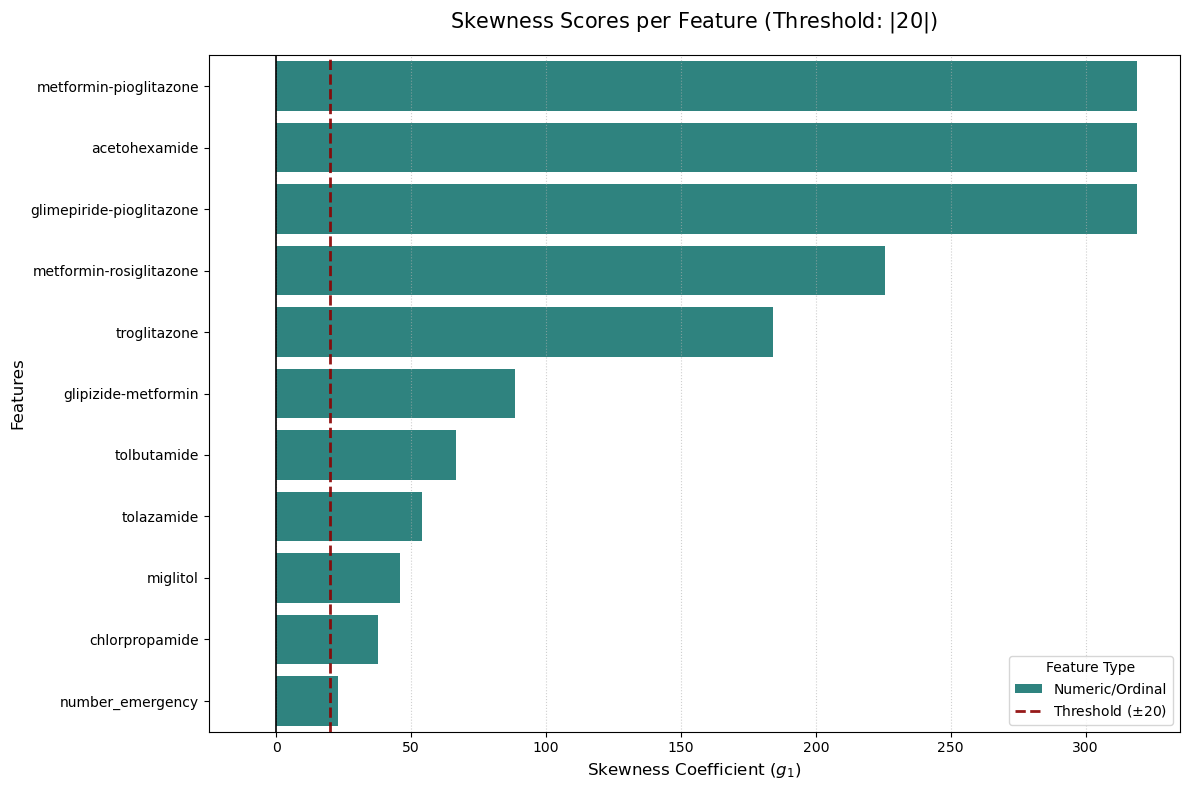

In [39]:
# --- YOUR EXISTING SKEW ANALYSIS LOGIC ---
upper_bound, lower_bound = 20, -20

# ... (Insert your loops here that populate non_encoded_skews and encoded_skews) ...

# --- NEW: CONSTRUCT THE SKEW_DF FOR PLOTTING ---
all_plot_data = []

for col, skew in non_encoded_skews:
    all_plot_data.append({'Feature': col, 'Skew': skew, 'Source': 'Numeric/Ordinal'})

for col, skew in encoded_skews:
    all_plot_data.append({'Feature': f"Grouped {col}", 'Skew': skew, 'Source': 'Categorical'})

skew_df = pd.DataFrame(all_plot_data)

if not skew_df.empty:
    skew_df['abs_skew'] = skew_df['Skew'].abs()
    skew_df = skew_df.sort_values(by='abs_skew', ascending=False)

    plt.figure(figsize=(12, 8))

    ax = sns.barplot(
        data=skew_df, 
        x='Skew', 
        y='Feature', 
        hue='Source', 
        dodge=False, 
        palette='viridis'
    )

    plt.axvline(0, color='black', linewidth=1.2, zorder=2)
    plt.axvline(upper_bound, color='darkred', linestyle='--', alpha=0.9, linewidth=2, label=f'Threshold ($\pm{upper_bound}$)', zorder=3)

    curr_xmin, curr_xmax = plt.xlim()
    plt.xlim(min(curr_xmin, lower_bound - 5), max(curr_xmax, upper_bound + 5)) 

    plt.title('Skewness Scores per Feature (Threshold: $|20|$)', fontsize=15, pad=20)
    plt.xlabel('Skewness Coefficient ($g_{1}$)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle=':', alpha=0.6, zorder=0)
    plt.legend(title='Feature Type', loc='lower right')

    plt.tight_layout()
    plt.show()
else:
    print("No features exceeded the skewness threshold of 20.")

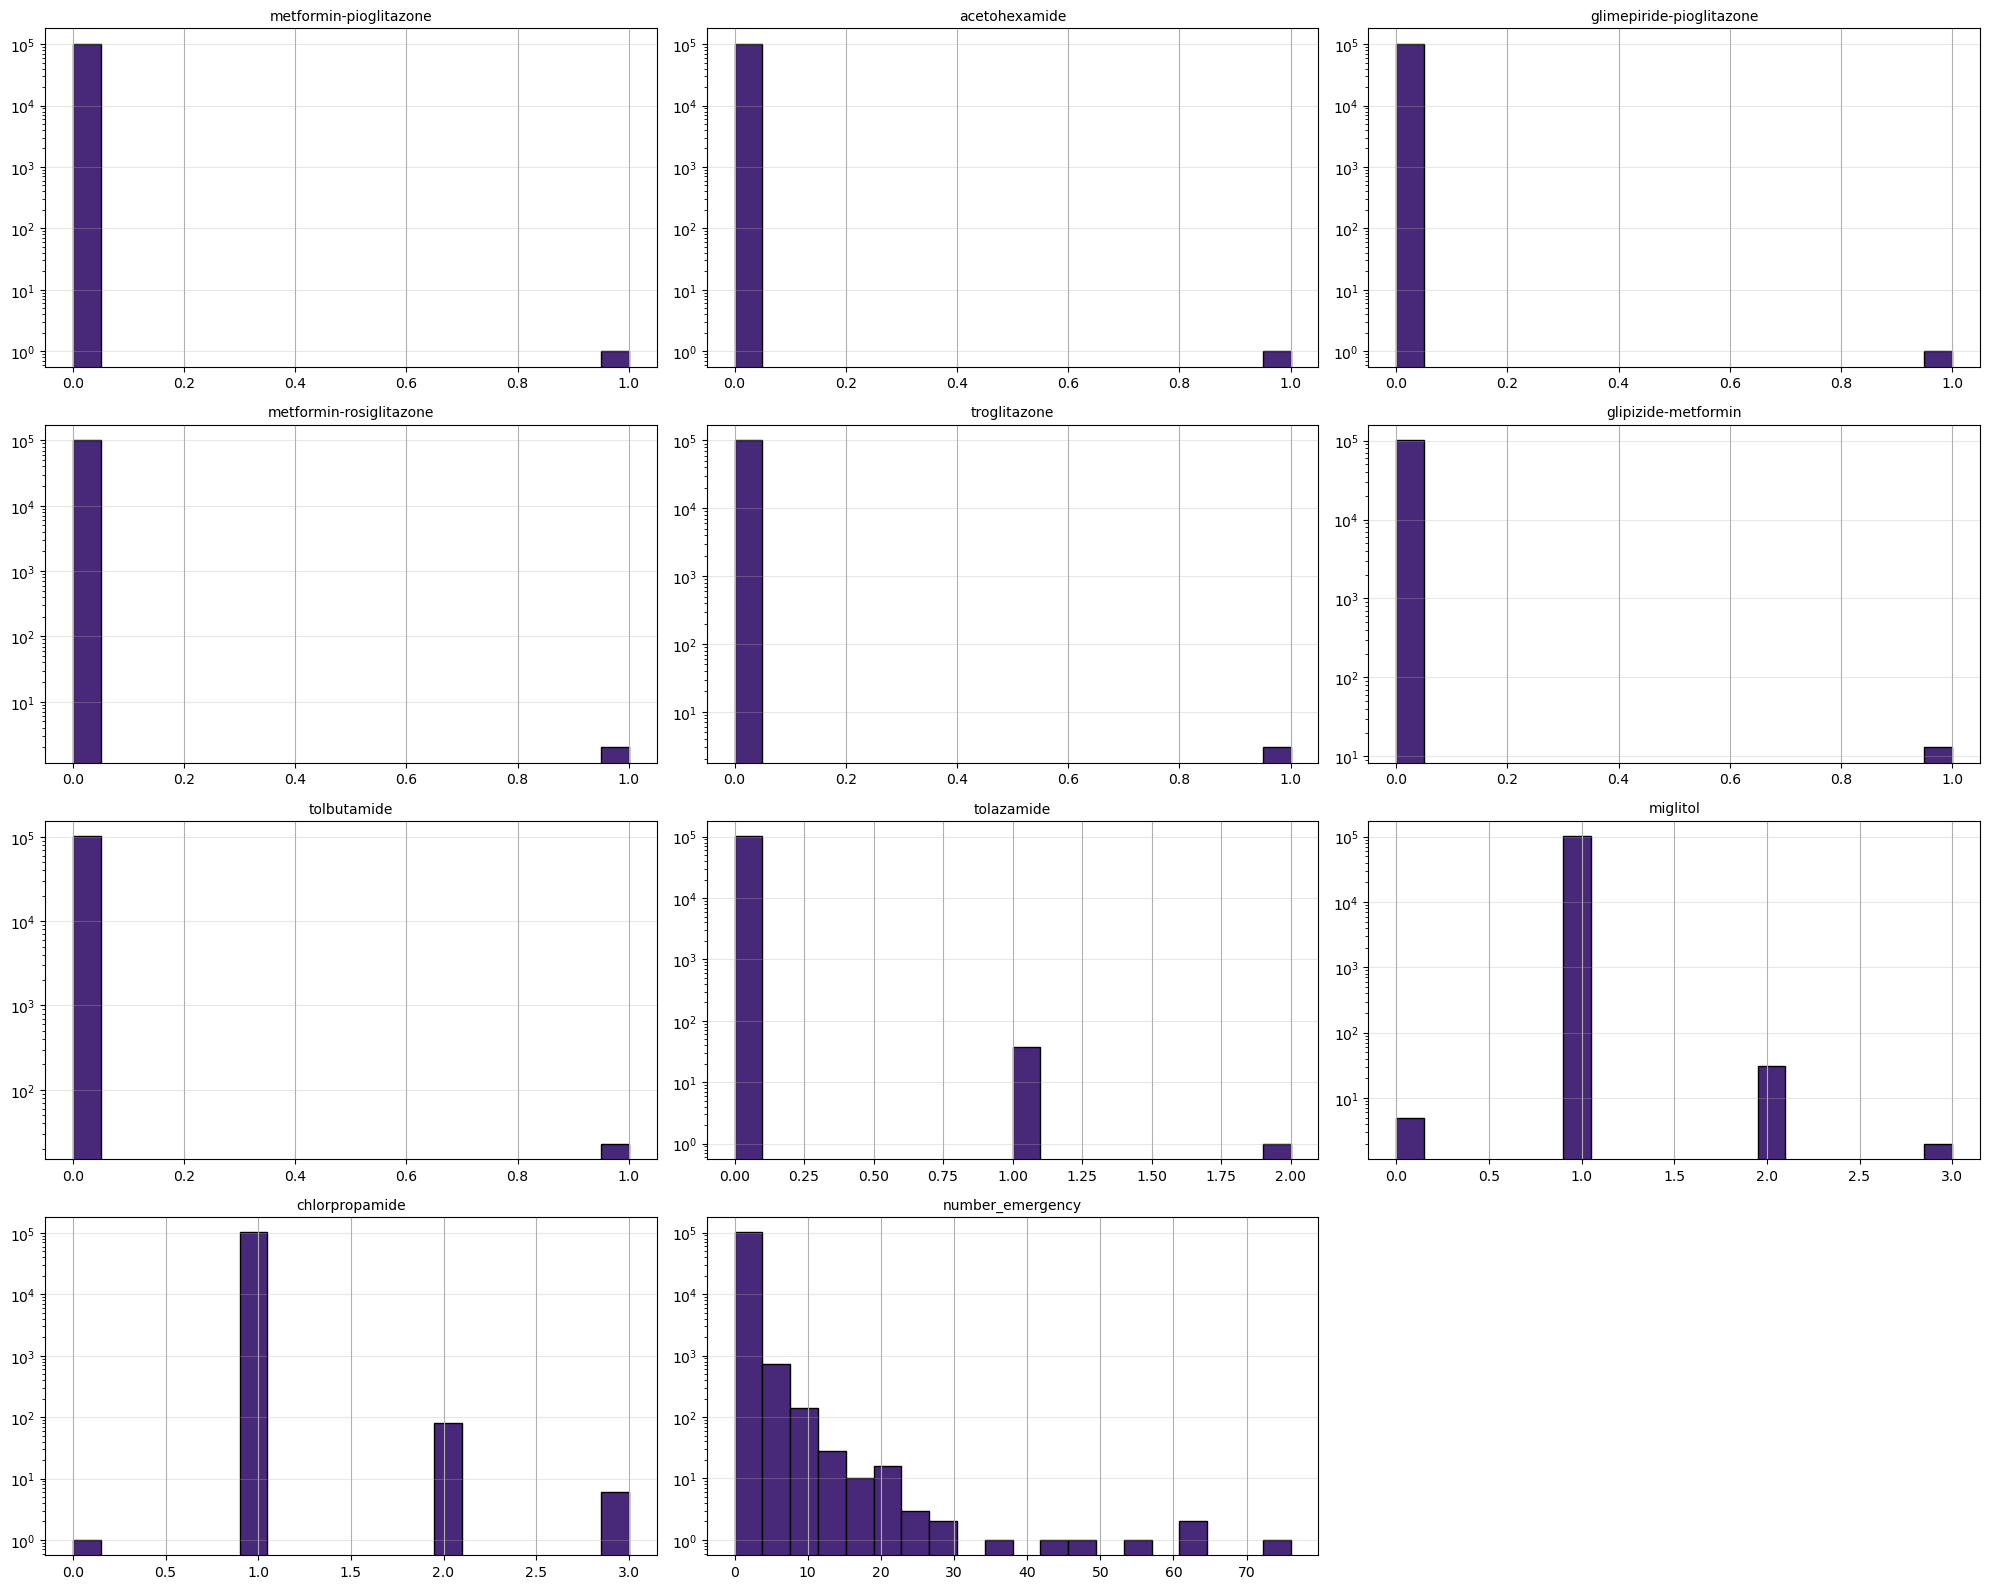

In [40]:
"""
Visualize Skew in Data via Histogram
"""
num_features = len(non_encoded_skews)
num_cols = 3
num_rows = num_features // num_cols + 1

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 4))
axes = axes.flatten()

for i, (col, skew) in enumerate(non_encoded_skews):
    ax = axes[i]
    
    df_6[col].hist(ax=ax, color='#482878', edgecolor='black', bins=20)
    
    ax.set_yscale('log')
    
    ax.set_title(f"{col}", fontsize=10)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
## Splitting Data for Export

In [41]:
"""
Add this last
"""
df_tr, df_te = train_test_split(df_6, test_size=.1, shuffle=True, random_state=seed)

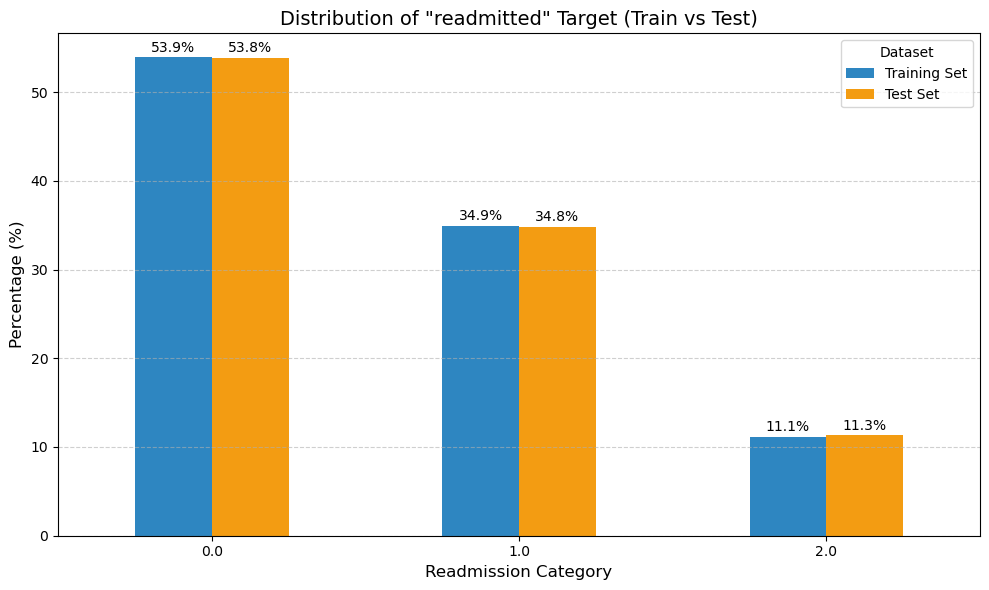

In [42]:
"""
Show Bar of `Readmitted` Target Feature
"""
train_dist = df_tr['readmitted'].value_counts(normalize=True) * 100
test_dist = df_te['readmitted'].value_counts(normalize=True) * 100

comparison_df = pd.DataFrame({
    'Training Set': train_dist,
    'Test Set': test_dist
})

ax = comparison_df.plot(kind='bar', figsize=(10, 6), color=['#2E86C1', '#F39C12'])

# Chart formatting
plt.title('Distribution of "readmitted" Target (Train vs Test)', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Readmission Category', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.6)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 7), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [43]:
"""
Export Steps
"""
pd_train = pd.DataFrame(df_tr)
pd_test = pd.DataFrame(df_te)

pd_train.to_csv("clean_training_data.csv")
pd_test.to_csv("clean_testing_data.csv")

---
# End of Pre-Processing